In [1]:
print("H")

H


In [2]:
# Experiment 1.1 — Baseline: Classical ML on Transaction Features
# Question: Can we detect illicit transactions WITHOUT using the graph?
# We use the 166 Elliptic features and ignore all edges entirely.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the three Elliptic CSVs
DATA = '../../data/elliptic_bitcoin_dataset/'

# features.csv has no header: col 0 = txId, col 1 = time step, cols 2..167 = 166 features
features = pd.read_csv(DATA + 'elliptic_txs_features.csv', header=None)
classes  = pd.read_csv(DATA + 'elliptic_txs_classes.csv')

# Column naming matches backend data_loader.py:
#   local_feat_0..93  = 94 local transaction features
#   agg_feat_0..71    = 72 aggregated neighbourhood features
features.columns = (
    ['txId', 'time_step']
    + [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)
features['txId'] = features['txId'].astype(str)

# Raw CSV uses '1' = illicit, '2' = licit, 'unknown' = unknown (numeric strings)
classes.columns = ['txId', 'class']
classes['txId']  = classes['txId'].astype(str)
classes['class'] = classes['class'].astype(str).map(
    {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
)

print('Features shape:', features.shape)
print('Classes shape :', classes.shape)
print(classes['class'].value_counts())

Features shape: (203769, 167)
Classes shape : (203769, 2)
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


In [5]:
# Merge features + labels, drop unknowns
df = features.merge(classes, on='txId')
df = df[df['class'] != 'unknown'].copy()

# Convert class to binary: illicit=1, licit=0
df['label'] = (df['class'] == 'illicit').astype(int)

print('Labelled transactions:', len(df))
print('Illicit:', df['label'].sum(), '  Licit:', (df['label'] == 0).sum())
print('Class ratio (illicit %):', round(df['label'].mean() * 100, 2), '%')

Labelled transactions: 46564
Illicit: 4545   Licit: 42019
Class ratio (illicit %): 9.76 %


In [7]:
# Temporal train / test split
# Train: time steps 1-34  |  Test: time steps 35-49
# Same split used in GNN experiments (exp1.2, exp1.3) for fair comparison.

FEATURE_COLS = (
    [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)

train_df = df[df['time_step'] <= 34]
test_df  = df[df['time_step'] >  34]

X_train, y_train = train_df[FEATURE_COLS].values, train_df['label'].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df['label'].values

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')
print(f'Train illicit rate: {y_train.mean():.2%}  |  Test illicit rate: {y_test.mean():.2%}')

Train: 29894 samples  |  Test: 16670 samples
Train illicit rate: 11.58%  |  Test illicit rate: 6.50%


In [8]:
# Helper to evaluate a trained model and return metrics dict
def evaluate(name, model, X, y):
    preds = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y, preds),          4),
        'Precision': round(precision_score(y, preds),         4),
        'Recall'   : round(recall_score(y, preds),            4),
        'F1'       : round(f1_score(y, preds),                4),
        'ROC-AUC'  : round(roc_auc_score(y, proba),           4),
        'PR-AUC'   : round(average_precision_score(y, proba), 4),
    }
    print(f'\n=== {name} ===')
    print(classification_report(y, preds, target_names=['licit', 'illicit']))
    return metrics

In [9]:
# Model 1: Logistic Regression
# class_weight='balanced' compensates for the illicit/licit imbalance automatically.

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_metrics = evaluate('Logistic Regression', lr, X_test, y_test)


=== Logistic Regression ===
              precision    recall  f1-score   support

       licit       0.99      0.75      0.85     15587
     illicit       0.19      0.87      0.31      1083

    accuracy                           0.75     16670
   macro avg       0.59      0.81      0.58     16670
weighted avg       0.94      0.75      0.82     16670



In [10]:
# Model 2: Random Forest (ensemble baseline)
# 300 trees, balanced class weights, all CPU cores.

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_metrics = evaluate('Random Forest', rf, X_test, y_test)


=== Random Forest ===
              precision    recall  f1-score   support

       licit       0.98      0.99      0.99     15587
     illicit       0.91      0.72      0.80      1083

    accuracy                           0.98     16670
   macro avg       0.94      0.86      0.90     16670
weighted avg       0.98      0.98      0.98     16670



In [11]:
# Summary table
results = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print(results.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                    
Logistic Regression    0.7537     0.1919  0.8689  0.3143   0.8864  0.2791
Random Forest          0.9771     0.9053  0.7239  0.8045   0.9406  0.7986


In [12]:
# Save results CSV so exp1.3 can load all three experiments together
results.to_csv('baseline_ml_results.csv')
print('Saved baseline_ml_results.csv')

Saved baseline_ml_results.csv


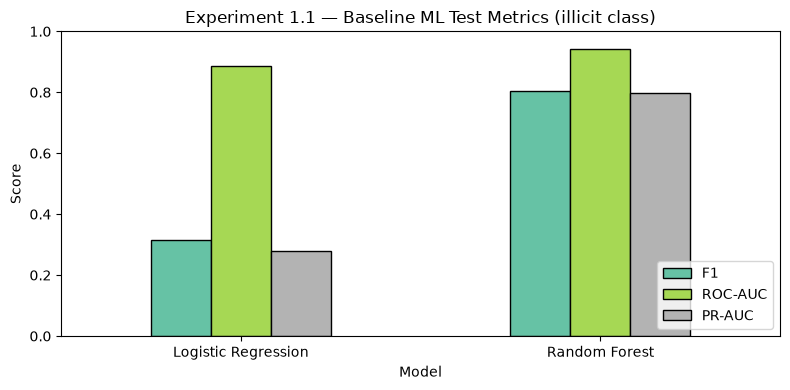

In [13]:
# Bar chart comparing F1, ROC-AUC, PR-AUC for both models
metrics_to_plot = ['F1', 'ROC-AUC', 'PR-AUC']
results[metrics_to_plot].plot(kind='bar', figsize=(8, 4), colormap='Set2', edgecolor='black')
plt.title('Experiment 1.1 — Baseline ML Test Metrics (illicit class)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('baseline_ml_metrics.png', dpi=120)
plt.show()

In [14]:
# OBSERVATION
# Transaction-level features provide a useful baseline for illicit transaction detection.
# Random Forest outperforms Logistic Regression, showing non-linear feature interactions matter.
#
# However, both models treat every transaction independently. They cannot capture the
# fact that fraudulent activity often propagates through chains of related transactions.
#
# Since fraud can propagate through transaction networks, we next incorporate graph
# structure using GraphSAGE (exp1.2).
print('Experiment 1.1 done.')

Experiment 1.1 done.
